# Capstone BBQ — Analysis Notebook

Universal experiment runner. Adjust `CONFIG` and re-run to compare surrogates, acquisition functions, and hyperparameters across all selected functions.

In [1]:
CONFIG = {
    # which functions to run (1–8)
    "functions": [1, 2, 3, 4, 5, 6, 7, 8],

    # which surrogates to compare
    "methods": ["GP", "SVR", "MLP"],

    # hyperparameters per surrogate
    "hyperparams": {
        "GP":  {"n_restarts": 5},
        "SVR": {"C": 1.0, "epsilon": 0.1, "n_bootstrap": 10},
        "MLP": {"hidden": 64, "n_layers": 2, "n_ensemble": 5, "epochs": 500, "lr": 1e-3},
    },

    # acquisition function: 'EI', 'UCB', or 'PI'
    "acquisition": "EI",
    "acquisition_params": {"xi": 0.01},

    # set True if optimising for maximum y, False for minimum
    "maximize": False,

    # candidate grid resolution (per dimension)
    "n_candidates": 1000,

    # how many next points to suggest per function
    "n_suggestions": 3,
}

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# make src importable when running from notebooks/
sys.path.insert(0, str(Path("__file__").resolve().parent.parent))

from src.loader import get_observations, summary
from src.surrogates.gp  import GPSurrogate
from src.surrogates.svr import SVRSurrogate
from src.surrogates.mlp import MLPSurrogate
from src.acquisition import get_acquisition, suggest_next

SURROGATE_REGISTRY = {
    "GP":  GPSurrogate,
    "SVR": SVRSurrogate,
    "MLP": MLPSurrogate,
}

## Data overview

In [3]:
summary()

function 01 | dim=2 | initial=11 | queries=4 | pending=0 | query rounds=[1, 2, 3, 4]
function 02 | dim=2 | initial=10 | queries=4 | pending=0 | query rounds=[1, 2, 3, 4]
function 03 | dim=3 | initial=15 | queries=4 | pending=0 | query rounds=[1, 2, 3, 4]
function 04 | dim=4 | initial=30 | queries=4 | pending=0 | query rounds=[1, 2, 3, 4]
function 05 | dim=4 | initial=20 | queries=4 | pending=0 | query rounds=[1, 2, 3, 4]
function 06 | dim=5 | initial=20 | queries=4 | pending=0 | query rounds=[1, 2, 3, 4]
function 07 | dim=6 | initial=30 | queries=4 | pending=0 | query rounds=[1, 2, 3, 4]
function 08 | dim=8 | initial=40 | queries=4 | pending=0 | query rounds=[1, 2, 3, 4]


## Run surrogates and generate suggestions

In [4]:
acq = get_acquisition(
    CONFIG["acquisition"],
    maximize=CONFIG["maximize"],
    **CONFIG["acquisition_params"],
)

# results[fn_id][method] = {"mean", "std", "suggestions", "scores"}
results = {}

for fn_id in CONFIG["functions"]:
    X, y = get_observations(fn_id)
    if len(X) == 0:
        print(f"function {fn_id:02d}: no observations, skipping")
        continue

    input_dim = X.shape[1]
    y_best = y.max() if CONFIG["maximize"] else y.min()

    # random candidate grid in [0, 1]^d
    rng = np.random.default_rng(42)
    X_candidates = rng.random((CONFIG["n_candidates"], input_dim))

    results[fn_id] = {}

    for method in CONFIG["methods"]:
        params = CONFIG["hyperparams"].get(method, {})
        model  = SURROGATE_REGISTRY[method](**params)

        try:
            model.fit(X, y)
            mean, std = model.predict(X_candidates)
            X_next, scores = suggest_next(
                X_candidates, mean, std, y_best, acq,
                n=CONFIG["n_suggestions"], exclude=X,
            )
            results[fn_id][method] = {
                "mean": mean, "std": std,
                "suggestions": X_next, "scores": scores,
                "error": None,
            }
            print(f"fn {fn_id:02d} | {method:4s} | y_best={y_best:.4g} | top score={scores[0]:.4g}")
        except Exception as e:
            results[fn_id][method] = {"error": str(e)}
            print(f"fn {fn_id:02d} | {method:4s} | ERROR: {e}")

fn 01 | GP   | y_best=-0.003606 | top score=1.203e-48
fn 01 | SVR  | y_best=-0.003606 | top score=0
fn 01 | MLP  | y_best=-0.003606 | top score=2.086e-272
fn 02 | GP   | y_best=-0.1741 | top score=0.02829
fn 02 | SVR  | y_best=-0.1741 | top score=0.0003249
fn 02 | MLP  | y_best=-0.1741 | top score=0.4447
fn 03 | GP   | y_best=-0.4474 | top score=0.007907
fn 03 | SVR  | y_best=-0.4474 | top score=0.0005332
fn 03 | MLP  | y_best=-0.4474 | top score=0.0575
fn 04 | GP   | y_best=-32.63 | top score=8.275
fn 04 | SVR  | y_best=-32.63 | top score=0.4264
fn 04 | MLP  | y_best=-32.63 | top score=8.422
fn 05 | GP   | y_best=0.1129 | top score=227.7
fn 05 | SVR  | y_best=0.1129 | top score=40.62
fn 05 | MLP  | y_best=0.1129 | top score=182.3
fn 06 | GP   | y_best=-2.639 | top score=13.65
fn 06 | SVR  | y_best=-2.639 | top score=0.02468
fn 06 | MLP  | y_best=-2.639 | top score=0.228
fn 07 | GP   | y_best=0.001934 | top score=0.08721
fn 07 | SVR  | y_best=0.001934 | top score=0.01033
fn 07 | MLP  |

## Suggestions per function

In [5]:
for fn_id, fn_results in results.items():
    X, y = get_observations(fn_id)
    print(f"\n{'='*60}")
    print(f"Function {fn_id:02d} | dim={X.shape[1]} | n_obs={len(X)} | y_best={y.min():.6g}")
    print(f"{'='*60}")

    for method, res in fn_results.items():
        if res["error"]:
            print(f"  {method}: ERROR — {res['error']}")
            continue
        print(f"\n  {method} — top {CONFIG['n_suggestions']} suggestions:")
        for i, (x, s) in enumerate(zip(res["suggestions"], res["scores"])):
            x_fmt = ", ".join(f"{v:.4f}" for v in x)
            print(f"    [{i+1}] x=[{x_fmt}]  score={s:.4g}")


Function 01 | dim=2 | n_obs=15 | y_best=-0.00360606

  GP — top 3 suggestions:
    [1] x=[0.5974, 0.6689]  score=1.203e-48
    [2] x=[0.6600, 0.7248]  score=4.11e-49
    [3] x=[0.5883, 0.6861]  score=3.921e-49

  SVR — top 3 suggestions:
    [1] x=[0.8457, 0.5201]  score=0
    [2] x=[0.8533, 0.2989]  score=0
    [3] x=[0.0177, 0.4533]  score=0

  MLP — top 3 suggestions:
    [1] x=[0.0272, 0.9585]  score=2.086e-272
    [2] x=[0.9856, 0.9850]  score=1.442e-272
    [3] x=[0.9584, 0.9955]  score=2.235e-277

Function 02 | dim=2 | n_obs=14 | y_best=-0.17409

  GP — top 3 suggestions:
    [1] x=[0.3336, 0.8984]  score=0.02829
    [2] x=[0.3483, 0.8651]  score=0.02826
    [3] x=[0.2894, 0.7961]  score=0.02778

  SVR — top 3 suggestions:
    [1] x=[0.0938, 0.4124]  score=0.0003249
    [2] x=[0.1050, 0.3986]  score=0.0003236
    [3] x=[0.2543, 0.9188]  score=0.0003204

  MLP — top 3 suggestions:
    [1] x=[0.0272, 0.9585]  score=0.4447
    [2] x=[0.0358, 0.9598]  score=0.4383
    [3] x=[0.1064

## Uncertainty comparison across surrogates

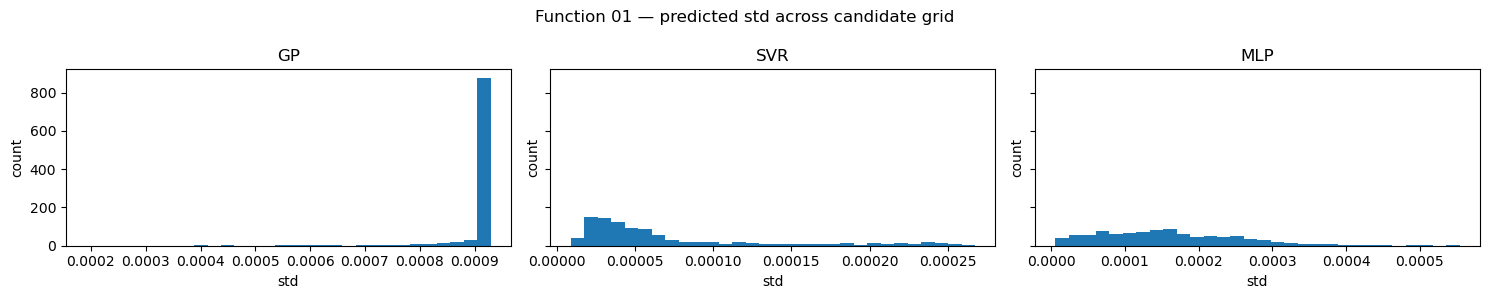

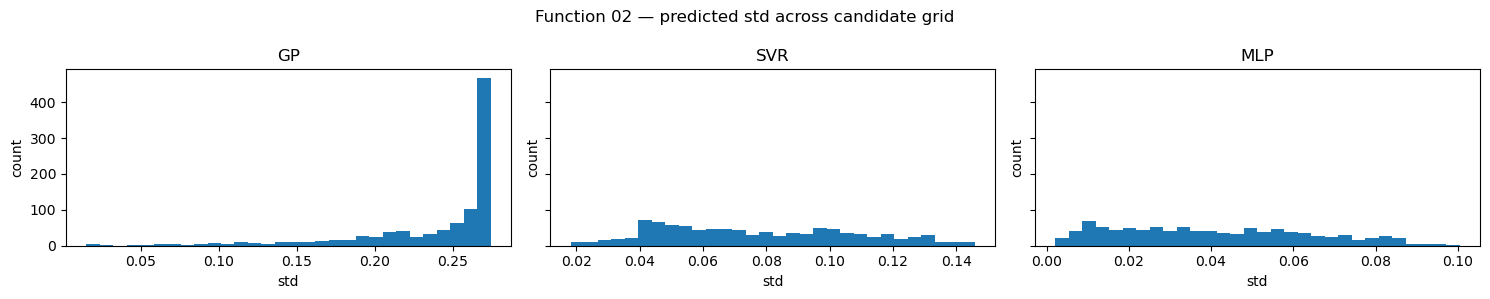

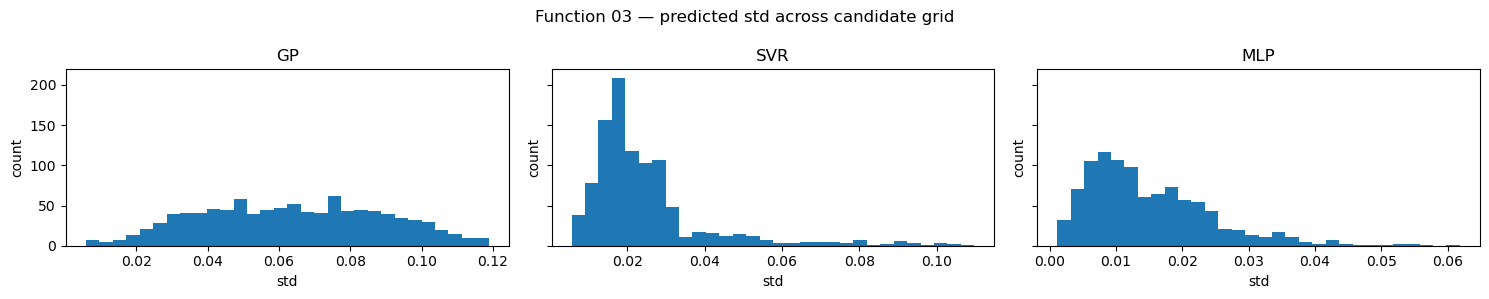

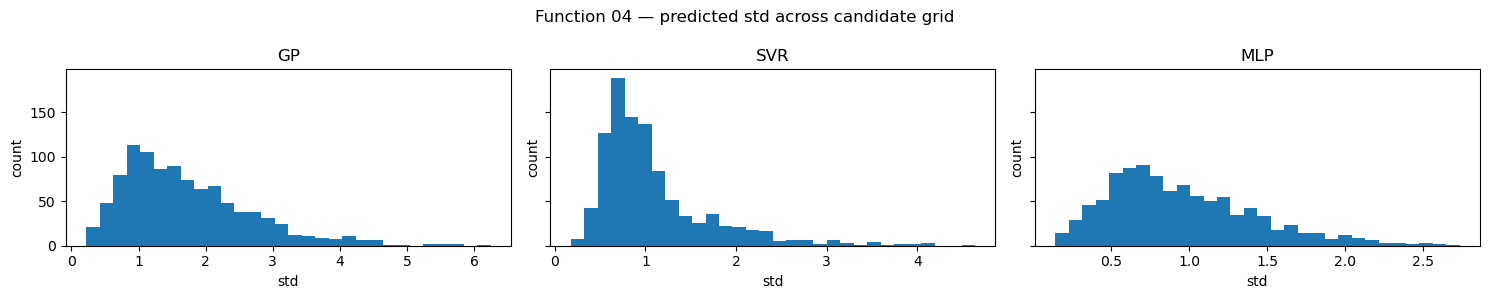

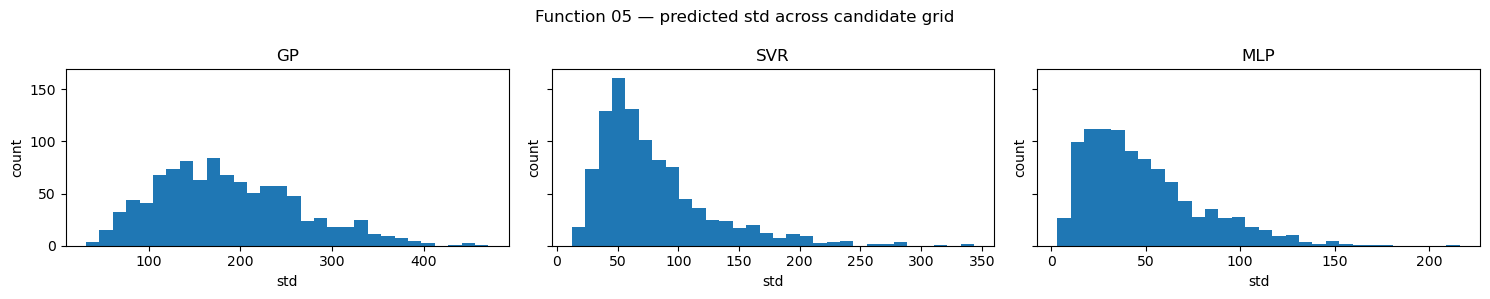

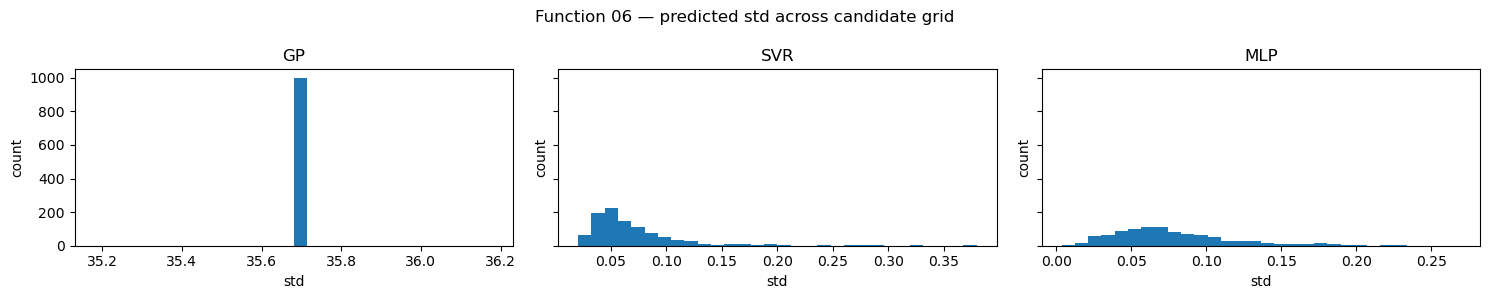

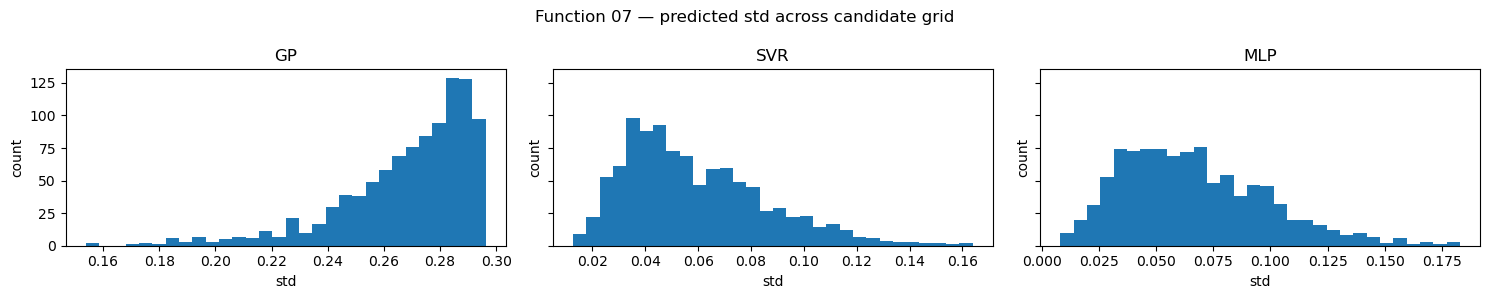

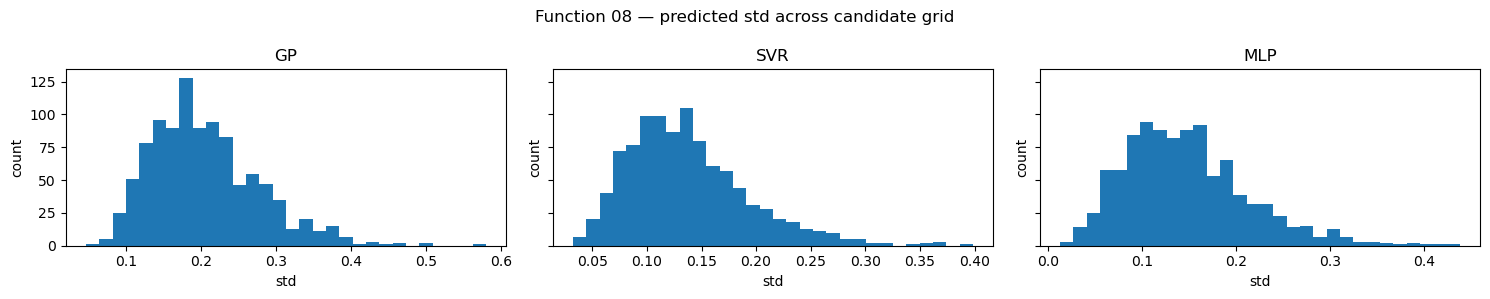

In [6]:
for fn_id, fn_results in results.items():
    methods_ok = [m for m, r in fn_results.items() if not r["error"]]
    if not methods_ok:
        continue

    fig, axes = plt.subplots(1, len(methods_ok), figsize=(5 * len(methods_ok), 3), sharey=True)
    if len(methods_ok) == 1:
        axes = [axes]

    fig.suptitle(f"Function {fn_id:02d} — predicted std across candidate grid", fontsize=12)

    for ax, method in zip(axes, methods_ok):
        std = fn_results[method]["std"]
        ax.hist(std, bins=30, edgecolor="none")
        ax.set_title(method)
        ax.set_xlabel("std")
        ax.set_ylabel("count")

    plt.tight_layout()
    plt.show()

## Summary table

In [7]:
rows = []
for fn_id, fn_results in results.items():
    X, y = get_observations(fn_id)
    for method, res in fn_results.items():
        if res["error"]:
            continue
        rows.append({
            "function":    fn_id,
            "dim":         X.shape[1],
            "n_obs":       len(X),
            "method":      method,
            "y_best":      y.min() if not CONFIG["maximize"] else y.max(),
            "top_score":   res["scores"][0],
            "mean_std":    res["std"].mean().round(4),
        })

df = pd.DataFrame(rows)
df

,function,dim,n_obs,method,y_best,top_score,mean_std
0,1,2,15,GP,-0.003606,1.203407e-48,0.0009
1,1,2,15,SVR,-0.003606,0.000000e+00,0.0001
2,1,2,15,MLP,-0.003606,2.085730e-272,0.0002
3,2,2,14,GP,-0.174090,2.828950e-02,0.2386
4,2,2,14,SVR,-0.174090,3.249421e-04,0.0769
5,2,2,14,MLP,-0.174090,4.446894e-01,0.0406
6,3,3,19,GP,-0.447368,7.906725e-03,0.0638
7,3,3,19,SVR,-0.447368,5.331957e-04,0.0249
8,3,3,19,MLP,-0.447368,5.750078e-02,0.0150
9,4,4,34,GP,-32.625660,8.274978e+00,1.7282


---
## Hyperparameter Tuning

Grid search with LOO-CV scoring for each surrogate. Adjust grids and `n_random_trials` below.
Set `n_random_trials=None` to run full grid search, or an integer for random search.

In [ ]:
TUNING_CONFIG = {
    # set to an integer to use random search instead of full grid search
    "n_random_trials": 20,

    "grids": {
        "GP": {
            "kernel":              ["RBF", "Matern"],
            "nu":                  [0.5, 1.5, 2.5],
            "alpha":               [1e-10, 1e-6, 1e-4, 1e-2],
            "length_scale_bounds": [(1e-2, 1e2), (1e-3, 1e3)],
            "n_restarts":          [3, 5, 10],
        },
        "SVR": {
            "C":       [0.1, 1.0, 10.0, 100.0],
            "epsilon": [0.01, 0.1, 0.5],
            "gamma":   ["scale", "auto"],
            "kernel":  ["rbf", "poly"],
        },
        "MLP": {
            "hidden":       [4, 8, 16, 32],
            "n_layers":     [1, 2, 3],
            "lr":           [1e-3, 1e-2],
            "weight_decay": [0, 1e-4, 1e-3],
            "epochs":       [50, 100],
            "n_ensemble":   [3, 5, 10],
        },
    },

    "acquisition_grids": {
        "EI":  {"xi":    [0.01, 0.05, 0.1, 0.5]},
        "UCB": {"kappa": [1.0, 2.0, 5.0]},
        "PI":  {"xi":    [0.01, 0.05, 0.1, 0.5]},
    },
}

In [9]:
from src.tuning import grid_search, tune_acquisition, results_to_table
from src.acquisition import ACQUISITION_REGISTRY

# tuning_results[fn_id][method] = sorted list of {params, loo_rmse, method}
tuning_results = {}

for fn_id in CONFIG["functions"]:
    X, y = get_observations(fn_id)
    if len(X) < 3:
        print(f"function {fn_id:02d}: too few observations for LOO-CV, skipping")
        continue

    tuning_results[fn_id] = {}
    print(f"\nfunction {fn_id:02d} | dim={X.shape[1]} | n_obs={len(X)}")

    for method in CONFIG["methods"]:
        surrogate_cls = SURROGATE_REGISTRY[method]
        param_grid    = TUNING_CONFIG["grids"][method]

        res = grid_search(
            surrogate_cls, param_grid, X, y,
            n_random_trials=TUNING_CONFIG["n_random_trials"],
        )
        tuning_results[fn_id][method] = res
        best = res[0]
        print(f"  {method:4s} | best loo_rmse={best['loo_rmse']:.6g} | {best['method']}")
        print(f"         best params: {best['params']}")


function 01 | dim=2 | n_obs=15


tuning:   0%|          | 0/20 [00:00<?, ?it/s]

  GP   | best loo_rmse=0.000959161 | random_search (n=20/144)
         best params: {'kernel': 'RBF', 'nu': 1.5, 'alpha': 1e-10, 'length_scale_bounds': (0.001, 1000.0), 'n_restarts': 5}


tuning:   0%|          | 0/20 [00:00<?, ?it/s]

  SVR  | best loo_rmse=0.000931107 | random_search (n=20/48)
         best params: {'C': 0.1, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'poly'}


...

  GP   | best loo_rmse=0.284902 | random_search (n=20/144)
         best params: {'kernel': 'Matern', 'nu': 1.5, 'alpha': 1e-06, 'length_scale_bounds': (0.001, 1000.0), 'n_restarts': 10}


tuning:   0%|          | 0/20 [00:00<?, ?it/s]

  SVR  | best loo_rmse=0.244779 | random_search (n=20/48)
         best params: {'C': 0.1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'poly'}


tuning:   0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Acquisition function tuning — run after surrogate tuning
# Uses the best surrogate params found above

acq_tuning_results = {}
acq_name  = CONFIG["acquisition"]
acq_cls   = ACQUISITION_REGISTRY[acq_name]
acq_grid  = TUNING_CONFIG["acquisition_grids"][acq_name]

for fn_id in tuning_results:
    X, y = get_observations(fn_id)
    acq_tuning_results[fn_id] = {}

    for method in CONFIG["methods"]:
        if method not in tuning_results[fn_id]:
            continue
        best_surrogate_params = tuning_results[fn_id][method][0]["params"]
        surrogate_cls = SURROGATE_REGISTRY[method]

        res = tune_acquisition(
            surrogate_cls, best_surrogate_params,
            acq_cls, acq_grid, X, y,
            maximize=CONFIG["maximize"],
        )
        acq_tuning_results[fn_id][method] = res

    best_acq = acq_tuning_results[fn_id]
    print(f"fn {fn_id:02d} acquisition tuning ({acq_name}):")
    for method, res in best_acq.items():
        print(f"  {method:4s} | best acq params={res[0]['params']} | rank_pct={res[0]['rank_percentile']:.3f}")

In [ ]:
# Tuning summary table
# model | best_hyperparams | loo_rmse | best_acq_params | rank_percentile | suggested_query

summary_rows = []

for fn_id in tuning_results:
    X, y = get_observations(fn_id)
    y_best = y.max() if CONFIG["maximize"] else y.min()
    rng = np.random.default_rng(42)
    X_candidates = rng.random((CONFIG["n_candidates"], X.shape[1]))

    for method in CONFIG["methods"]:
        if method not in tuning_results[fn_id]:
            continue

        best_params    = tuning_results[fn_id][method][0]["params"]
        best_loo_rmse  = tuning_results[fn_id][method][0]["loo_rmse"]
        best_acq_res   = acq_tuning_results[fn_id][method][0]
        best_acq_params = best_acq_res["params"]
        rank_pct        = best_acq_res["rank_percentile"]

        # generate suggestion with tuned params
        try:
            acq = acq_cls(maximize=CONFIG["maximize"], **best_acq_params)
            model = SURROGATE_REGISTRY[method](**best_params)
            model.fit(X, y)
            mean, std = model.predict(X_candidates)
            X_next, scores = suggest_next(
                X_candidates, mean, std, y_best, acq, n=1, exclude=X
            )
            suggestion = "[" + ", ".join(f"{v:.4f}" for v in X_next[0]) + "]"
        except Exception as e:
            suggestion = f"ERROR: {e}"

        summary_rows.append({
            "function":        fn_id,
            "model":           method,
            "loo_rmse":        round(best_loo_rmse, 6),
            "best_hyperparams": str(best_params),
            "best_acq_params": str(best_acq_params),
            "rank_percentile": round(rank_pct, 3),
            "suggested_query": suggestion,
        })

df_tuning = pd.DataFrame(summary_rows)
pd.set_option("display.max_colwidth", 80)
df_tuning